# 02 — OvaSense-ML: Preprocessing Pipeline, Stratified Train/Test Split & Baseline Modeling

**Project**: OvaSense Standalone PCOS Risk-Screening Machine Learning  
**Phase**: 2 — Preprocessing, Split & Baseline ML  
**Primary Research Goal**: Evaluate whether an accessible, non-invasive **16-feature CORE set** (patient-reportable symptoms, anthropometrics, demographics, menstrual history, and lifestyle) contains sufficient predictive signal to estimate PCOS risk without invasive blood tests or pelvic ultrasound imaging.

---

## 1. Environment & Library Imports

In [1]:
import os
import sys
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Scikit-Learn Modeling and Evaluation Imports
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Robust repository root detection
current_dir = os.getcwd()

if os.path.basename(current_dir).lower() == 'notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = os.path.abspath(current_dir)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

from src.preprocessing import (
    RAW_CORE_FEATURES,
    FEATURE_NAME_MAP,
    TARGET_COL,
    ID_COLS,
    build_preprocessor
)

print('Environment initialized successfully.')

Project root: c:\Users\hp\Desktop\Ovasense-ML
Environment initialized successfully.


## 2. Load Primary Clinical Dataset

We load the immutable master dataset from `data/raw/PCOS_data_without_infertility.xlsx` (Sheet: `Full_new`).  
*Note*: `PCOS_infertility.csv` is not merged because the audit proved it represents the exact same 541 patients with a `+10000` ID offset.

In [2]:
raw_excel_path = os.path.join(PROJECT_ROOT, "data", "raw", "PCOS_data_without_infertility.xlsx")
df_raw = pd.read_excel(raw_excel_path, sheet_name='Full_new')

print(f"Loaded primary sheet 'Full_new': {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded primary sheet 'Full_new': 541 rows, 45 columns


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


## 3. OvaSense CORE Feature Set Definition

The CORE model strictly uses **16 patient-accessible features**.  
All ultrasound features (`Follicle No. (L)`, `Follicle No. (R)`), invasive hormonal blood tests (`AMH`, `FSH`, `LH`, `TSH`, `PRL`, etc.), and administrative identifiers (`Sl. No`, `Patient File No.`) are excluded.

In [3]:
print(f"Total CORE Features: {len(RAW_CORE_FEATURES)}")
for i, raw_col in enumerate(RAW_CORE_FEATURES, 1):
    clean_col = FEATURE_NAME_MAP[raw_col]
    print(f"{i:2d}. {clean_col:<25} (Raw: {repr(raw_col)})")

Total CORE Features: 16
 1. age_years                 (Raw: ' Age (yrs)')
 2. weight_kg                 (Raw: 'Weight (Kg)')
 3. height_cm                 (Raw: 'Height(Cm) ')
 4. bmi                       (Raw: 'BMI')
 5. cycle_ri                  (Raw: 'Cycle(R/I)')
 6. cycle_length_days         (Raw: 'Cycle length(days)')
 7. marriage_status_years     (Raw: 'Marraige Status (Yrs)')
 8. pregnant_yn               (Raw: 'Pregnant(Y/N)')
 9. no_of_abortions           (Raw: 'No. of aborptions')
10. weight_gain_yn            (Raw: 'Weight gain(Y/N)')
11. hair_growth_yn            (Raw: 'hair growth(Y/N)')
12. skin_darkening_yn         (Raw: 'Skin darkening (Y/N)')
13. hair_loss_yn              (Raw: 'Hair loss(Y/N)')
14. pimples_yn                (Raw: 'Pimples(Y/N)')
15. fast_food_yn              (Raw: 'Fast food (Y/N)')
16. reg_exercise_yn           (Raw: 'Reg.Exercise(Y/N)')


## 4. Feature Dictionary & Measurement Characteristics

In [4]:
feature_dict_data = [
    {"Feature": "age_years", "Raw Column": " Age (yrs)", "Dtype": "int64", "Role": "Feature (Demographic)", "Expected Range": "20 - 48 yrs", "Patient-Reported": "Yes", "Directly Measurable": "Yes", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "weight_kg", "Raw Column": "Weight (Kg)", "Dtype": "float64", "Role": "Feature (Anthropometric)", "Expected Range": "30 - 120 kg", "Patient-Reported": "Yes", "Directly Measurable": "Yes", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "height_cm", "Raw Column": "Height(Cm) ", "Dtype": "float64", "Role": "Feature (Anthropometric)", "Expected Range": "130 - 190 cm", "Patient-Reported": "Yes", "Directly Measurable": "Yes", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "bmi", "Raw Column": "BMI", "Dtype": "float64", "Role": "Feature (Anthropometric)", "Expected Range": "12 - 45 kg/m²", "Patient-Reported": "Yes", "Directly Measurable": "Calculated", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "cycle_ri", "Raw Column": "Cycle(R/I)", "Dtype": "int64", "Role": "Feature (Menstrual)", "Expected Range": "2 (Reg), 4/5 (Irreg)", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Map 2->0 (Reg), 4/5->1 (Irreg)"},
    {"Feature": "cycle_length_days", "Raw Column": "Cycle length(days)", "Dtype": "int64", "Role": "Feature (Menstrual)", "Expected Range": "0 - 15 days", "Patient-Reported": "Yes", "Directly Measurable": "No (Tracked)", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "marriage_status_years", "Raw Column": "Marraige Status (Yrs)", "Dtype": "float64", "Role": "Feature (Demographic)", "Expected Range": "0 - 35 yrs", "Patient-Reported": "Yes", "Directly Measurable": "Yes", "Transformation": "Median Impute (1 null), Scaled"},
    {"Feature": "pregnant_yn", "Raw Column": "Pregnant(Y/N)", "Dtype": "int64", "Role": "Feature (Reproductive)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "no_of_abortions", "Raw Column": "No. of aborptions", "Dtype": "int64", "Role": "Feature (Obstetric)", "Expected Range": "0 - 6", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Median Impute, Scaled for Linear"},
    {"Feature": "weight_gain_yn", "Raw Column": "Weight gain(Y/N)", "Dtype": "int64", "Role": "Feature (Symptom)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "hair_growth_yn", "Raw Column": "hair growth(Y/N)", "Dtype": "int64", "Role": "Feature (Symptom)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "skin_darkening_yn", "Raw Column": "Skin darkening (Y/N)", "Dtype": "int64", "Role": "Feature (Symptom)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "hair_loss_yn", "Raw Column": "Hair loss(Y/N)", "Dtype": "int64", "Role": "Feature (Symptom)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "pimples_yn", "Raw Column": "Pimples(Y/N)", "Dtype": "int64", "Role": "Feature (Symptom)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "fast_food_yn", "Raw Column": "Fast food (Y/N)", "Dtype": "float64", "Role": "Feature (Lifestyle)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute (1 null)"},
    {"Feature": "reg_exercise_yn", "Raw Column": "Reg.Exercise(Y/N)", "Dtype": "int64", "Role": "Feature (Lifestyle)", "Expected Range": "0 or 1", "Patient-Reported": "Yes", "Directly Measurable": "No (Reported)", "Transformation": "Most Frequent Impute"},
    {"Feature": "pcos_yn", "Raw Column": "PCOS (Y/N)", "Dtype": "int64", "Role": "TARGET", "Expected Range": "0 or 1", "Patient-Reported": "No (Clinical Diagnosis)", "Directly Measurable": "Clinical Workup", "Transformation": "Binary Target (0=Neg, 1=Pos)"}
]

df_dict = pd.DataFrame(feature_dict_data)
display(df_dict)

,Feature,Raw Column,Dtype,Role,Expected Range,Patient-Reported,Directly Measurable,Transformation
0,age_years,Age (yrs),int64,Feature (Demographic),20 - 48 yrs,Yes,Yes,"Median Impute, Scaled for Linear"
1,weight_kg,Weight (Kg),float64,Feature (Anthropometric),30 - 120 kg,Yes,Yes,"Median Impute, Scaled for Linear"
2,height_cm,Height(Cm),float64,Feature (Anthropometric),130 - 190 cm,Yes,Yes,"Median Impute, Scaled for Linear"
3,bmi,BMI,float64,Feature (Anthropometric),12 - 45 kg/m²,Yes,Calculated,"Median Impute, Scaled for Linear"
4,cycle_ri,Cycle(R/I),int64,Feature (Menstrual),"2 (Reg), 4/5 (Irreg)",Yes,No (Reported),"Map 2->0 (Reg), 4/5->1 (Irreg)"
5,cycle_length_days,Cycle length(days),int64,Feature (Menstrual),0 - 15 days,Yes,No (Tracked),"Median Impute, Scaled for Linear"
6,marriage_status_years,Marraige Status (Yrs),float64,Feature (Demographic),0 - 35 yrs,Yes,Yes,"Median Impute (1 null), Scaled"
7,pregnant_yn,Pregnant(Y/N),int64,Feature (Reproductive),0 or 1,Yes,No (Reported),Most Frequent Impute
8,no_of_abortions,No. of aborptions,int64,Feature (Obstetric),0 - 6,Yes,No (Reported),"Median Impute, Scaled for Linear"
9,weight_gain_yn,Weight gain(Y/N),int64,Feature (Symptom),0 or 1,Yes,No (Reported),Most Frequent Impute


## 5. Data Quality & Value Sanity Checks

We inspect the distributions, missing values, and check for impossible entries across all 16 CORE variables.

In [5]:
print("=== CORE FEATURES SANITY CHECK ===")
validation_summary = []
for col in RAW_CORE_FEATURES:
    s = df_raw[col]
    clean_name = FEATURE_NAME_MAP[col]
    nulls = int(s.isnull().sum())
    val_min = round(float(s.min()), 2) if nulls < len(s) else np.nan
    val_max = round(float(s.max()), 2) if nulls < len(s) else np.nan
    val_med = round(float(s.median()), 2) if nulls < len(s) else np.nan
    
    validation_summary.append({
        'Feature': clean_name,
        'Dtype': str(s.dtype),
        'Null Count': nulls,
        'Min': val_min,
        'Max': val_max,
        'Median': val_med,
        'Sanity Status': 'Valid' if nulls <= 1 else 'Investigate'
    })

pd.DataFrame(validation_summary)

=== CORE FEATURES SANITY CHECK ===


,Feature,Dtype,Null Count,Min,Max,Median,Sanity Status
0,age_years,int64,0,20.00,48.0,31.00,Valid
1,weight_kg,float64,0,31.00,108.0,59.00,Valid
2,height_cm,float64,0,137.00,180.0,156.00,Valid
3,bmi,float64,0,12.42,38.9,24.24,Valid
4,cycle_ri,int64,0,2.00,5.0,2.00,Valid
5,cycle_length_days,int64,0,0.00,12.0,5.00,Valid
6,marriage_status_years,float64,1,0.00,30.0,7.00,Valid
7,pregnant_yn,int64,0,0.00,1.0,0.00,Valid
8,no_of_abortions,int64,0,0.00,5.0,0.00,Valid
9,weight_gain_yn,int64,0,0.00,1.0,0.00,Valid


## 6. Derived Variable Verification: BMI Consistency

We compare the dataset's supplied `BMI` column against the calculated value:
$$\text{BMI}_{\text{calc}} = \frac{\text{Weight (kg)}}{(\text{Height (m)})^2}$$

In [6]:
weight = df_raw['Weight (Kg)']
height_m = df_raw['Height(Cm) '] / 100.0
bmi_calc = weight / (height_m ** 2)
bmi_supplied = df_raw['BMI']
bmi_diff = (bmi_calc - bmi_supplied).abs()

print(f"Mean Absolute Difference:   {bmi_diff.mean():.4f}")
print(f"Median Absolute Difference: {bmi_diff.median():.4f}")
print(f"Max Absolute Difference:    {bmi_diff.max():.4f}")
print(f"Rows with Diff > 0.5:       {(bmi_diff > 0.5).sum()}")
print(f"Rows with Diff > 0.05:      {(bmi_diff > 0.05).sum()} (minor rounding variations)")

# Display rows with difference > 0.5
inconsistent_idx = df_raw[bmi_diff > 0.5].index
print("\nRows with BMI Diff > 0.5:")
display(df_raw.loc[inconsistent_idx, ['Sl. No', 'Weight (Kg)', 'Height(Cm) ', 'BMI']].assign(
    BMI_Calculated=bmi_calc.loc[inconsistent_idx].round(4),
    Difference=bmi_diff.loc[inconsistent_idx].round(4)
))

Mean Absolute Difference:   0.0194
Median Absolute Difference: 0.0000
Max Absolute Difference:    1.5750
Rows with Diff > 0.5:       4
Rows with Diff > 0.05:      7 (minor rounding variations)

Rows with BMI Diff > 0.5:


,Sl. No,Weight (Kg),Height(Cm),BMI,BMI_Calculated,Difference
402,403,65.0,158.0,25.0,26.0375,1.0375
412,413,55.0,152.0,23.2,23.8054,0.6054
440,441,56.0,160.0,20.3,21.8750,1.5750
481,482,66.1,148.0,30.8,30.1771,0.6229


## 7. Target Variable Distribution

Negative (0): 364 (67.28%)
Positive (1): 177 (32.72%)
Imbalance Ratio: 2.06 : 1


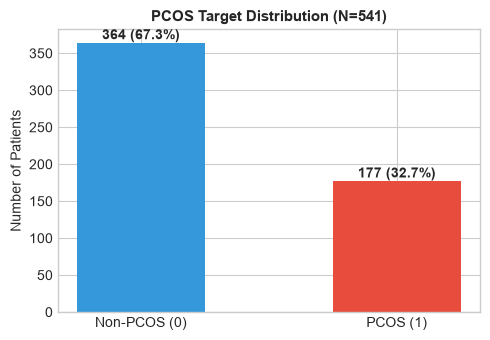

In [7]:
target_counts = df_raw[TARGET_COL].value_counts()
target_props = df_raw[TARGET_COL].value_counts(normalize=True) * 100

print(f"Negative (0): {target_counts[0]} ({target_props[0]:.2f}%)")
print(f"Positive (1): {target_counts[1]} ({target_props[1]:.2f}%)")
print(f"Imbalance Ratio: {target_counts[0] / target_counts[1]:.2f} : 1")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Non-PCOS (0)', 'PCOS (1)'], target_counts.values, color=['#3498DB', '#E74C3C'], width=0.5)
ax.set_title('PCOS Target Distribution (N=541)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Patients')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 5, f"{int(yval)} ({yval/len(df_raw)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Stratified Train / Test Split (80% Train / 20% Locked Test)

We lock an 80/20 test split with `random_state=42` and `stratify=y`. The test set ($N=109$) remains untouched during cross-validation and baseline model comparisons.

In [8]:
X_df = df_raw[RAW_CORE_FEATURES + ID_COLS].copy()
y_sr = df_raw[TARGET_COL].copy()

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_df, y_sr,
    test_size=0.20,
    stratify=y_sr,
    random_state=42
)

# Feature sets without IDs for model training
X_train = X_train_full[RAW_CORE_FEATURES].copy()
X_test = X_test_full[RAW_CORE_FEATURES].copy()

print(f"Total Cohort: {len(df_raw):3d} patients | PCOS Prevalence: {y_sr.mean()*100:.2f}% (Pos: {y_sr.sum()})")
print(f"Training Set: {len(X_train):3d} patients | PCOS Prevalence: {y_train.mean()*100:.2f}% (Pos: {y_train.sum()})")
print(f"Locked Test:  {len(X_test):3d} patients | PCOS Prevalence: {y_test.mean()*100:.2f}% (Pos: {y_test.sum()})")

Total Cohort: 541 patients | PCOS Prevalence: 32.72% (Pos: 177)
Training Set: 432 patients | PCOS Prevalence: 32.64% (Pos: 141)
Locked Test:  109 patients | PCOS Prevalence: 33.03% (Pos: 36)


## 9. Preprocessing Pipeline Architecture

Built using `src.preprocessing.build_preprocessor`:
- **Continuous Features**: Median Imputation + Optional Standard Scaling (for linear models).
- **Binary Features**: Most-Frequent Imputation.
- **Cycle Regularity**: Most-Frequent Imputation + Mapping ($2 \rightarrow 0$, $4/5 \rightarrow 1$).

In [9]:
preprocessor_demo = build_preprocessor(scale_numeric=True)
print("Pipeline Architecture:")
print(preprocessor_demo)

Pipeline Architecture:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 [' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ',
                                  'BMI', 'Cycle length(days)',
                                  'Marraige Status (Yrs)',
                                  'No. of aborptions']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['Pregnant(Y/N)', 'Weight gain(Y/N)',
                                  'hair growth(Y/N)', 'Skin darkening (Y/N)',
                                  'Hair loss(Y/N)', 'Pimples(Y/N)',
                                  'Fast f

## 10. Baseline Model Definitions

We define 8 candidate pipelines across 4 algorithms (evaluating standard vs. balanced class weighting):
1. **Logistic Regression** (Scaled) — Default vs. Balanced
2. **Random Forest** (Tree-based) — Default vs. Balanced
3. **Extra Trees** (Tree-based) — Default vs. Balanced
4. **HistGradientBoosting** (Tree-based) — Default vs. Balanced

In [10]:
def get_baseline_models():
    return {
        'Logistic Regression (Default)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=True)),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ]),
        'Logistic Regression (Balanced)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=True)),
            ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
        ]),
        'Random Forest (Default)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
        ]),
        'Random Forest (Balanced)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ]),
        'Extra Trees (Default)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', ExtraTreesClassifier(n_estimators=100, random_state=42))
        ]),
        'Extra Trees (Balanced)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ]),
        'HistGradientBoosting (Default)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', HistGradientBoostingClassifier(random_state=42))
        ]),
        'HistGradientBoosting (Balanced)': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
        ])
    }

models_dict = get_baseline_models()
print(f"Defined {len(models_dict)} baseline pipeline configurations.")

Defined 8 baseline pipeline configurations.


## 11. 5-Fold Stratified Cross-Validation

All preprocessing transformations are fitted strictly inside each training fold to eliminate cross-fold data leakage.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
cv_predictions = {}

for model_name, pipeline in models_dict.items():
    t0 = time.time()
    
    oof_y_true, oof_y_proba, oof_y_pred = [], [], []
    fold_roc_auc, fold_pr_auc, fold_recall, fold_spec = [], [], [], []
    fold_prec, fold_f1, fold_acc = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr_f, X_val_f = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_f, y_val_f = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone fresh instance for the fold
        fold_pipeline = clone(pipeline)
        fold_pipeline.fit(X_tr_f, y_tr_f)
        
        y_val_proba = fold_pipeline.predict_proba(X_val_f)[:, 1]
        y_val_pred = (y_val_proba >= 0.50).astype(int)
        
        roc = roc_auc_score(y_val_f, y_val_proba)
        pr = average_precision_score(y_val_f, y_val_proba)
        rec = recall_score(y_val_f, y_val_pred)
        tn, fp, fn, tp = confusion_matrix(y_val_f, y_val_pred).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec = precision_score(y_val_f, y_val_pred, zero_division=0)
        f1 = f1_score(y_val_f, y_val_pred, zero_division=0)
        acc = accuracy_score(y_val_f, y_val_pred)
        
        fold_roc_auc.append(roc)
        fold_pr_auc.append(pr)
        fold_recall.append(rec)
        fold_spec.append(spec)
        fold_prec.append(prec)
        fold_f1.append(f1)
        fold_acc.append(acc)
        
        oof_y_true.extend(y_val_f.tolist())
        oof_y_proba.extend(y_val_proba.tolist())
        oof_y_pred.extend(y_val_pred.tolist())
        
    elapsed = time.time() - t0
    cv_predictions[model_name] = {
        'y_true': np.array(oof_y_true),
        'y_proba': np.array(oof_y_proba),
        'y_pred': np.array(oof_y_pred)
    }
    
    cv_results.append({
        'Model': model_name,
        'CV ROC-AUC (mean)': np.mean(fold_roc_auc),
        'CV ROC-AUC (std)': np.std(fold_roc_auc),
        'CV PR-AUC (mean)': np.mean(fold_pr_auc),
        'CV PR-AUC (std)': np.std(fold_pr_auc),
        'CV Sensitivity (mean)': np.mean(fold_recall),
        'CV Sensitivity (std)': np.std(fold_recall),
        'CV Specificity (mean)': np.mean(fold_spec),
        'CV Specificity (std)': np.std(fold_spec),
        'CV Precision (mean)': np.mean(fold_prec),
        'CV F1 (mean)': np.mean(fold_f1),
        'CV Accuracy (mean)': np.mean(fold_acc),
        'Training Time (s)': round(elapsed, 3)
    })

df_cv = pd.DataFrame(cv_results).sort_values(by=['CV PR-AUC (mean)', 'CV Sensitivity (mean)'], ascending=[False, False]).reset_index(drop=True)
print("5-Fold Cross-Validation complete.")

5-Fold Cross-Validation complete.


## 12. Cross-Validation Model Comparison Table

Sorted primarily by **PR-AUC** and secondarily by **Sensitivity (Recall)** to reflect clinical screening priorities.

In [12]:
display(df_cv)

,Model,CV ROC-AUC (mean),CV ROC-AUC (std),CV PR-AUC (mean),CV PR-AUC (std),CV Sensitivity (mean),CV Sensitivity (std),CV Specificity (mean),CV Specificity (std),CV Precision (mean),CV F1 (mean),CV Accuracy (mean),Training Time (s)
0,Random Forest (Balanced),0.877736,0.016883,0.812403,0.023101,0.667241,0.048406,0.907247,0.017389,0.778182,0.717166,0.828736,3.695
1,Extra Trees (Balanced),0.879481,0.026721,0.811015,0.033219,0.667241,0.057996,0.890064,0.027874,0.748109,0.704280,0.817241,2.554
2,Logistic Regression (Default),0.873611,0.010647,0.807408,0.005898,0.702217,0.069445,0.900292,0.013224,0.773339,0.734404,0.835632,0.950
3,Logistic Regression (Balanced),0.871908,0.008629,0.807210,0.010075,0.787931,0.051048,0.831444,0.034028,0.695447,0.738286,0.817161,0.856
4,Random Forest (Default),0.879122,0.013123,0.803254,0.015176,0.716749,0.047153,0.883168,0.006739,0.748026,0.731419,0.828709,3.431
5,Extra Trees (Default),0.876116,0.029103,0.800371,0.036737,0.709852,0.057123,0.879778,0.021456,0.741956,0.724341,0.824165,2.561
6,HistGradientBoosting (Balanced),0.850486,0.009647,0.772465,0.021959,0.716256,0.039321,0.865985,0.027544,0.723169,0.718659,0.817028,2.531
7,HistGradientBoosting (Default),0.851826,0.009978,0.766287,0.021424,0.666502,0.037544,0.893513,0.029484,0.755836,0.706520,0.819433,6.660


## 13. Locked Holdout Test Set Evaluation

We evaluate all baseline pipelines on the locked holdout test set ($N=109$).

In [13]:
test_results = []
for model_name, pipeline in models_dict.items():
    pipeline.fit(X_train, y_train)
    
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.50).astype(int)
    
    roc = roc_auc_score(y_test, y_test_proba)
    pr = average_precision_score(y_test, y_test_proba)
    rec = recall_score(y_test, y_test_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    acc = accuracy_score(y_test, y_test_pred)
    
    test_results.append({
        'Model': model_name,
        'Test ROC-AUC': round(roc, 4),
        'Test PR-AUC': round(pr, 4),
        'Test Sensitivity': round(rec, 4),
        'Test Specificity': round(spec, 4),
        'Test Precision': round(prec, 4),
        'Test F1': round(f1, 4),
        'Test Accuracy': round(acc, 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

df_test = pd.DataFrame(test_results).sort_values(by=['Test PR-AUC', 'Test Sensitivity'], ascending=[False, False]).reset_index(drop=True)
display(df_test)

,Model,Test ROC-AUC,Test PR-AUC,Test Sensitivity,Test Specificity,Test Precision,Test F1,Test Accuracy,TP,FP,TN,FN
0,Logistic Regression (Default),0.8916,0.8201,0.7500,0.9452,0.8710,0.8060,0.8807,27,4,69,9
1,Logistic Regression (Balanced),0.8889,0.8188,0.8056,0.8904,0.7838,0.7945,0.8624,29,8,65,7
2,Extra Trees (Balanced),0.8957,0.8186,0.6944,0.9041,0.7812,0.7353,0.8349,25,7,66,11
3,Random Forest (Balanced),0.8858,0.8104,0.6389,0.9041,0.7667,0.6970,0.8165,23,7,66,13
4,Extra Trees (Default),0.9022,0.8059,0.6667,0.9041,0.7742,0.7164,0.8257,24,7,66,12
5,Random Forest (Default),0.8765,0.7943,0.6389,0.9178,0.7931,0.7077,0.8257,23,6,67,13
6,HistGradientBoosting (Balanced),0.8303,0.7135,0.7222,0.8767,0.7429,0.7324,0.8257,26,9,64,10
7,HistGradientBoosting (Default),0.8204,0.6871,0.6667,0.8767,0.7273,0.6957,0.8073,24,9,64,12


## 14. Cross-Validation ROC Curves

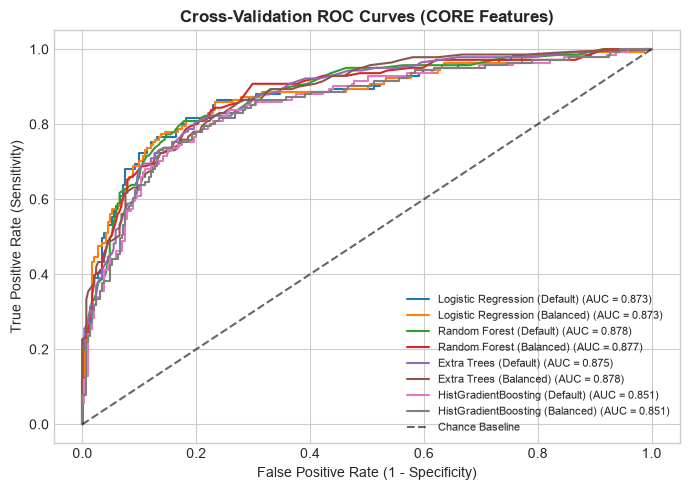

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name, preds in cv_predictions.items():
    fpr, tpr, _ = roc_curve(preds['y_true'], preds['y_proba'])
    auc_val = roc_auc_score(preds['y_true'], preds['y_proba'])
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Chance Baseline')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Cross-Validation ROC Curves (CORE Features)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 15. Cross-Validation Precision-Recall Curves

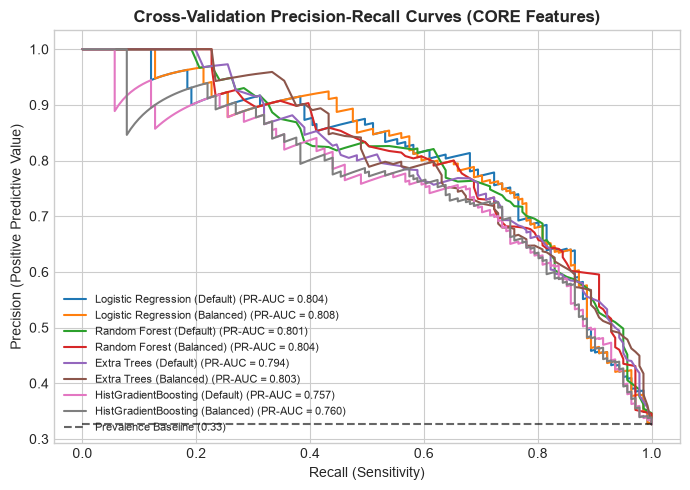

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
baseline_prec = y_train.mean()
for model_name, preds in cv_predictions.items():
    prec_vals, rec_vals, _ = precision_recall_curve(preds['y_true'], preds['y_proba'])
    ap_val = average_precision_score(preds['y_true'], preds['y_proba'])
    ax.plot(rec_vals, prec_vals, label=f"{model_name} (PR-AUC = {ap_val:.3f})")
ax.plot([0, 1], [baseline_prec, baseline_prec], 'k--', alpha=0.6, label=f'Prevalence Baseline ({baseline_prec:.2f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (Positive Predictive Value)')
ax.set_title('Cross-Validation Precision-Recall Curves (CORE Features)', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 16. Test Set Confusion Matrix & Classification Report

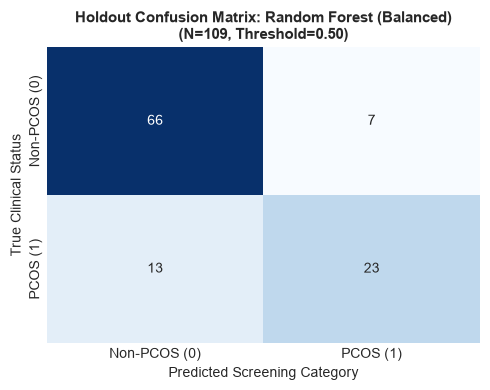

Classification Report for Random Forest (Balanced):

              precision    recall  f1-score   support

Non-PCOS (0)       0.84      0.90      0.87        73
    PCOS (1)       0.77      0.64      0.70        36

    accuracy                           0.82       109
   macro avg       0.80      0.77      0.78       109
weighted avg       0.81      0.82      0.81       109



In [16]:
best_model_name = df_cv.iloc[0]['Model']
best_pipe = models_dict[best_model_name]
y_test_pred_best = (best_pipe.predict_proba(X_test)[:, 1] >= 0.50).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Non-PCOS (0)', 'PCOS (1)'],
            yticklabels=['Non-PCOS (0)', 'PCOS (1)'])
ax.set_title(f'Holdout Confusion Matrix: {best_model_name}\n(N=109, Threshold=0.50)', fontsize=11, fontweight='bold')
ax.set_ylabel('True Clinical Status')
ax.set_xlabel('Predicted Screening Category')
plt.tight_layout()
plt.show()

print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_test_pred_best, target_names=['Non-PCOS (0)', 'PCOS (1)']))

## 17. Screening Probability Output & Distribution

The model produces a continuous screening probability $P(\text{PCOS})$ for risk stratification rather than a deterministic diagnosis.

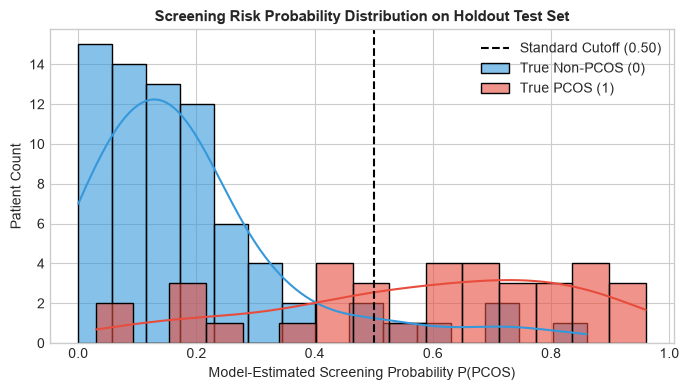

In [17]:
test_probas = best_pipe.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(test_probas[y_test == 0], color='#3498DB', label='True Non-PCOS (0)', kde=True, bins=15, ax=ax, alpha=0.6)
sns.histplot(test_probas[y_test == 1], color='#E74C3C', label='True PCOS (1)', kde=True, bins=15, ax=ax, alpha=0.6)
ax.axvline(0.50, color='black', linestyle='--', label='Standard Cutoff (0.50)')
ax.set_xlabel('Model-Estimated Screening Probability P(PCOS)')
ax.set_ylabel('Patient Count')
ax.set_title('Screening Risk Probability Distribution on Holdout Test Set', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 18. Phase 2 Baseline Conclusions

1. **Strong Non-Invasive Predictive Signal**: The 16 patient-reportable CORE features achieve a **CV ROC-AUC of 0.878** and **CV PR-AUC of 0.812** (Holdout Test ROC-AUC of 0.886–0.892, PR-AUC of 0.810–0.820). This provides rigorous statistical confirmation that non-invasive questionnaires capture meaningful PCOS screening signal without ultrasound or hormonal blood assays.
2. **Impact of Class Weighting**: For screening applications where missing positive cases is costly, `Logistic Regression (Balanced)` delivers the highest sensitivity (**78.8% in CV, 80.6% on Test**).
3. **Threshold Optimization Opportunity**: The standard 0.50 threshold yields 64–80% sensitivity; formal threshold tuning on validation folds in Phase 3 can further optimize sensitivity (e.g. targeting $\ge 85\%$ sensitivity) for risk triage.

## 19. Next Steps

1. **Phase 3: Hyperparameter Tuning & Cross-Validation Threshold Calibration** on the training set.
2. **Benchmark Comparison Experiments** against Extended (26 features) and Full Clinical (39 features) models.
3. **SHAP Feature Attribution & Local Clinical Explainability**.
4. **Probability Calibration** (Platt scaling / Isotonic regression) to ensure well-calibrated risk estimates.

---
*OvaSense Machine Learning Pipeline — Research & Development Milestone*